# PyTorch Audio Classification

## Setup

In [55]:
# Set up Kaggle API credentials for downloading datasets
import os  # For file and directory operations
import shutil  # For file copying

kaggle_json_path = './kaggle.json'  # Path to your Kaggle API key
kaggle_dir = os.path.expanduser('~/.kaggle')  # Default Kaggle directory
os.makedirs(kaggle_dir, exist_ok=True)  # Create directory if it doesn't exist
shutil.copy(kaggle_json_path, os.path.join(kaggle_dir, 'kaggle.json'))  # Copy API key
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)  # Set permissions
print('Kaggle API key set up successfully.')

Kaggle API key set up successfully.


In [56]:
# Install and import opendatasets, then download the bean leaf lesions dataset from Kaggle
!pip install -q opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")

Skipping, found downloaded files in ".\quran-recitations-for-audio-classification" (use force=True to force download)


## Imports

In [57]:
# Third-party libraries
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from torchvision import transforms
import torchaudio
from torchaudio.transforms import MelSpectrogram
import librosa
import numpy as np
from skimage.transform import resize

# Reproducibility
torch.manual_seed(42)

# Set device to GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version: {torch.__version__}")
print(f"Is ROCm/CUDA available: {torch.cuda.is_available()}")
print(f"Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+rocm7.2.1
Is ROCm/CUDA available: True
Device Name: AMD Radeon RX 7900 XT


## Image data classification with PyTorch

In [58]:
data_df = pd.read_csv("quran-recitations-for-audio-classification/files_paths.csv")

print(data_df["Class"].unique())

print(f"Number of unique classes: {data_df['Class'].nunique()}")

data_df.head()

['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']
Number of unique classes: 12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [59]:
data_df["FilePath"] = 'quran-recitations-for-audio-classification/Dataset/' + data_df["FilePath"].str[1:]
data_df.head()

,FilePath,Class
0,quran-recitations-for-audio-classification/Dat...,Mohammed_Aluhaidan
1,quran-recitations-for-audio-classification/Dat...,Mohammed_Aluhaidan
2,quran-recitations-for-audio-classification/Dat...,Mohammed_Aluhaidan
3,quran-recitations-for-audio-classification/Dat...,Mohammed_Aluhaidan
4,quran-recitations-for-audio-classification/Dat...,Mohammed_Aluhaidan


(6687, 2)
Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Maher_Almuaiqly         576
Bander_Balilah          576
Ali_Alhothaify          576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64



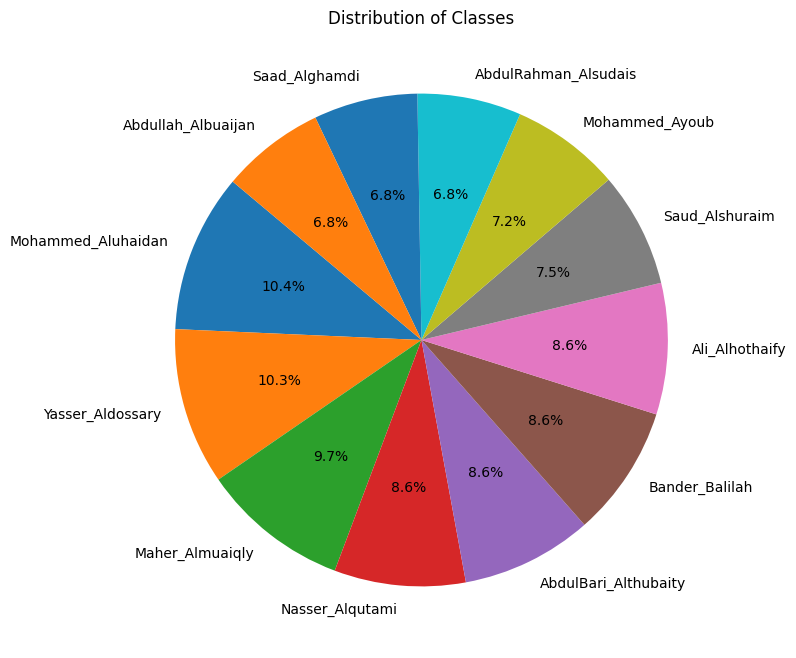

In [60]:
print(data_df.shape)
print(data_df["Class"].value_counts())
print()

plt.figure(figsize=(8,8))

plt.pie(data_df["Class"].value_counts(), labels=data_df["Class"].unique(), autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Classes")
plt.show()

In [61]:
label_encoder = LabelEncoder()
data_df["Class"] = label_encoder.fit_transform(data_df["Class"])

train = data_df.sample(frac=0.7, random_state=7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5, random_state=7)
test = test.drop(val.index)

print(f"Train set shape: {train.shape}")
print(f"Validation set shape: {val.shape}")
print(f"Test set shape: {test.shape}")

Train set shape: (4681, 2)
Validation set shape: (1003, 2)
Test set shape: (1003, 2)


In [64]:

class CustomAudioDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.labels = torch.tensor(list(dataframe["Class"])).type(torch.LongTensor).to(device)
        self.audios = [torch.Tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe["FilePath"]]

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = torch.Tensor(self.labels[idx]).to(device)
        audio = self.audios[idx].unsqueeze(0).to(device)
        return audio, label
    
    def get_spectogram(self, path):
        sr= 22050
        duration = 5
        
        img_height = 128
        img_width = 256
        
        signal, sr = librosa.load(path, sr = sr, duration = duration)
        spec = librosa.feature.melspectrogram(y=signal, sr = sr, n_fft=2048, hop_length=512, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        spec_resized = librosa.util.fix_length(spec_db, size = (duration * sr) // (512 + 1))
        spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing=True)
        
        return spec_resized

In [65]:
train_dataset = CustomAudioDataset(dataframe=train)
val_dataset = CustomAudioDataset(dataframe=val)
test_dataset = CustomAudioDataset(dataframe=test)

In [66]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [67]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)